# BA820 Project M4: Mapping the Economic Burden of Childcare Across US Counties

**Project Title**: Mapping the Economic Burden of Childcare Across US Counties

**Section and Team Number**: B1 Team 9

**Name**: Li-Hsin Chang




## Upload Data

In [52]:
import pandas as pd
url = "https://raw.githubusercontent.com/cindych12/BA820-project/refs/heads/main/childcare_costs.csv"
df = pd.read_csv(url)
df.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,21.55,4.07,80.92,81.40,104.95,104.95,85.92,83.45,83.45,81.40
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,21.96,5.19,83.42,85.68,105.11,105.11,87.59,87.39,87.39,85.68
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,21.28,4.13,85.92,89.96,105.28,105.28,89.26,91.33,91.33,89.96
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,22.80,4.77,88.43,94.25,105.45,105.45,90.93,95.28,95.28,94.25
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,22.88,4.84,90.93,98.53,105.61,105.61,92.60,99.22,99.22,98.53


In [53]:
url="https://raw.githubusercontent.com/cindych12/BA820-project/refs/heads/main/counties.csv"
df2 = pd.read_csv(url)
df2.head()

,county_fips_code,county_name,state_name,state_abbreviation
0,1001,Autauga County,Alabama,AL
1,1003,Baldwin County,Alabama,AL
2,1005,Barbour County,Alabama,AL
3,1007,Bibb County,Alabama,AL
4,1009,Blount County,Alabama,AL


## Data Preprocessing & Understanding

### Merge Data




In [54]:
df_merged = df.merge(df2,on="county_fips_code",how="left")
df_merged.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL


### Data Cleaning

In [55]:
df_merged.columns

Index(['county_fips_code', 'study_year', 'unr_16', 'funr_16', 'munr_16',
       'unr_20to64', 'funr_20to64', 'munr_20to64', 'flfpr_20to64',
       'flfpr_20to64_under6', 'flfpr_20to64_6to17',
       'flfpr_20to64_under6_6to17', 'mlfpr_20to64', 'pr_f', 'pr_p', 'mhi_2018',
       'me_2018', 'fme_2018', 'mme_2018', 'total_pop', 'one_race',
       'one_race_w', 'one_race_b', 'one_race_i', 'one_race_a', 'one_race_h',
       'one_race_other', 'two_races', 'hispanic', 'households',
       'h_under6_both_work', 'h_under6_f_work', 'h_under6_m_work',
       'h_under6_single_m', 'h_6to17_both_work', 'h_6to17_fwork',
       'h_6to17_mwork', 'h_6to17_single_m', 'emp_m', 'memp_m', 'femp_m',
       'emp_service', 'memp_service', 'femp_service', 'emp_sales',
       'memp_sales', 'femp_sales', 'emp_n', 'memp_n', 'femp_n', 'emp_p',
       'memp_p', 'femp_p', 'mcsa', 'mfccsa', 'mc_infant', 'mc_toddler',
       'mc_preschool', 'mfcc_infant', 'mfcc_toddler', 'mfcc_preschool',
       'county_name', 'state_n

In [56]:
childcare = df_merged.copy()

In [57]:
childcare = childcare[
    (childcare["mc_infant"] > 0) &
    (childcare["mhi_2018"] > 0)
]

In [58]:
childcare.isna().sum().sort_values(ascending=False)

,0
mfccsa,251
mfcc_preschool,251
mfcc_infant,251
mfcc_toddler,251
county_fips_code,0
...,...
mc_preschool,0
mc_toddler,0
county_name,0
state_name,0


In [59]:
childcare_clean = childcare.dropna(
    subset=["mfcc_infant", "mfcc_toddler", "mfcc_preschool","mfccsa"]
)

In [60]:
childcare_clean.isna().sum().sort_values(ascending=False)

,0
county_fips_code,0
study_year,0
unr_16,0
funr_16,0
munr_16,0
...,...
mfcc_toddler,0
mfcc_preschool,0
county_name,0
state_name,0


In [61]:
childcare_clean.duplicated(
    subset=["county_fips_code","study_year"]
).sum()

np.int64(0)

In [62]:
childcare_clean.dtypes

,0
county_fips_code,int64
study_year,int64
unr_16,float64
funr_16,float64
munr_16,float64
...,...
mfcc_toddler,float64
mfcc_preschool,float64
county_name,object
state_name,object


In [63]:
childcare_clean.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL


In [64]:
print(childcare_clean.columns)

Index(['county_fips_code', 'study_year', 'unr_16', 'funr_16', 'munr_16',
       'unr_20to64', 'funr_20to64', 'munr_20to64', 'flfpr_20to64',
       'flfpr_20to64_under6', 'flfpr_20to64_6to17',
       'flfpr_20to64_under6_6to17', 'mlfpr_20to64', 'pr_f', 'pr_p', 'mhi_2018',
       'me_2018', 'fme_2018', 'mme_2018', 'total_pop', 'one_race',
       'one_race_w', 'one_race_b', 'one_race_i', 'one_race_a', 'one_race_h',
       'one_race_other', 'two_races', 'hispanic', 'households',
       'h_under6_both_work', 'h_under6_f_work', 'h_under6_m_work',
       'h_under6_single_m', 'h_6to17_both_work', 'h_6to17_fwork',
       'h_6to17_mwork', 'h_6to17_single_m', 'emp_m', 'memp_m', 'femp_m',
       'emp_service', 'memp_service', 'femp_service', 'emp_sales',
       'memp_sales', 'femp_sales', 'emp_n', 'memp_n', 'femp_n', 'emp_p',
       'memp_p', 'femp_p', 'mcsa', 'mfccsa', 'mc_infant', 'mc_toddler',
       'mc_preschool', 'mfcc_infant', 'mfcc_toddler', 'mfcc_preschool',
       'county_name', 'state_n

In [65]:
childcare_clean.shape
childcare_clean[["mc_infant","mhi_2018"]].describe()

,mc_infant,mhi_2018
count,23342.000000,23342.000000
mean,145.695372,50428.437534
std,53.554511,13158.072756
min,36.300000,19841.920000
25%,108.570000,41946.270000
50%,133.835000,48541.050000
75%,165.010000,56204.135000
max,470.000000,136268.000000


Choose features

In [125]:
#choose features
cost_cols = ["mc_infant", "mc_toddler", "mc_preschool", "mcsa", "mfcc_infant", "mfcc_toddler", "mfcc_preschool", "mfccsa"]
count_cols = ["total_pop", "households", "h_6to17_fwork", "h_6to17_single_m", "h_under6_single_m", "h_under6_f_work", "h_6to17_mwork",]

In [67]:
childcare_clean["afford_mc_infant"] = childcare_clean["mc_infant"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mc_toddler"] = childcare_clean["mc_toddler"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mc_preschool"] = childcare_clean["mc_preschool"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mcsa"]=childcare_clean["mcsa"]/childcare_clean["mhi_2018"]
childcare_clean["afford_mfcc_infant"] = childcare_clean["mfcc_infant"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mfcc_toddler"] = childcare_clean["mfcc_toddler"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mfcc_preschool"] = childcare_clean["mfcc_preschool"] / childcare_clean["mhi_2018"]
childcare_clean["afford_mfccsa"] = childcare_clean["mfccsa"] / childcare_clean["mhi_2018"]

afford_cols = ["afford_mc_infant","afford_mc_toddler","afford_mc_preschool","afford_mcsa",
               "afford_mfcc_infant","afford_mfcc_toddler","afford_mfcc_preschool","afford_mfccsa"]

/tmp/ipython-input-2332548826.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-2332548826.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-2332548826.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-233

In [68]:
childcare_clean[afford_cols]

,afford_mc_infant,afford_mc_toddler,afford_mc_preschool,afford_mcsa,afford_mfcc_infant,afford_mfcc_toddler,afford_mfcc_preschool,afford_mfccsa
0,0.001795,0.001795,0.001470,0.001384,0.001427,0.001427,0.001392,0.001392
1,0.001746,0.001746,0.001455,0.001385,0.001451,0.001451,0.001423,0.001423
2,0.001704,0.001704,0.001445,0.001391,0.001478,0.001478,0.001456,0.001456
3,0.001747,0.001747,0.001506,0.001465,0.001578,0.001578,0.001561,0.001561
4,0.001785,0.001785,0.001566,0.001537,0.001677,0.001677,0.001666,0.001666
...,...,...,...,...,...,...,...,...
34562,0.002578,0.002106,0.002169,0.001595,0.001937,0.001937,0.001950,0.001976
34563,0.002293,0.001941,0.001941,0.001548,0.001812,0.001812,0.001812,0.001812
34564,0.002283,0.002005,0.001944,0.001684,0.001953,0.001901,0.001888,0.001863
34565,0.002059,0.001882,0.001764,0.001662,0.001911,0.001812,0.001787,0.001740


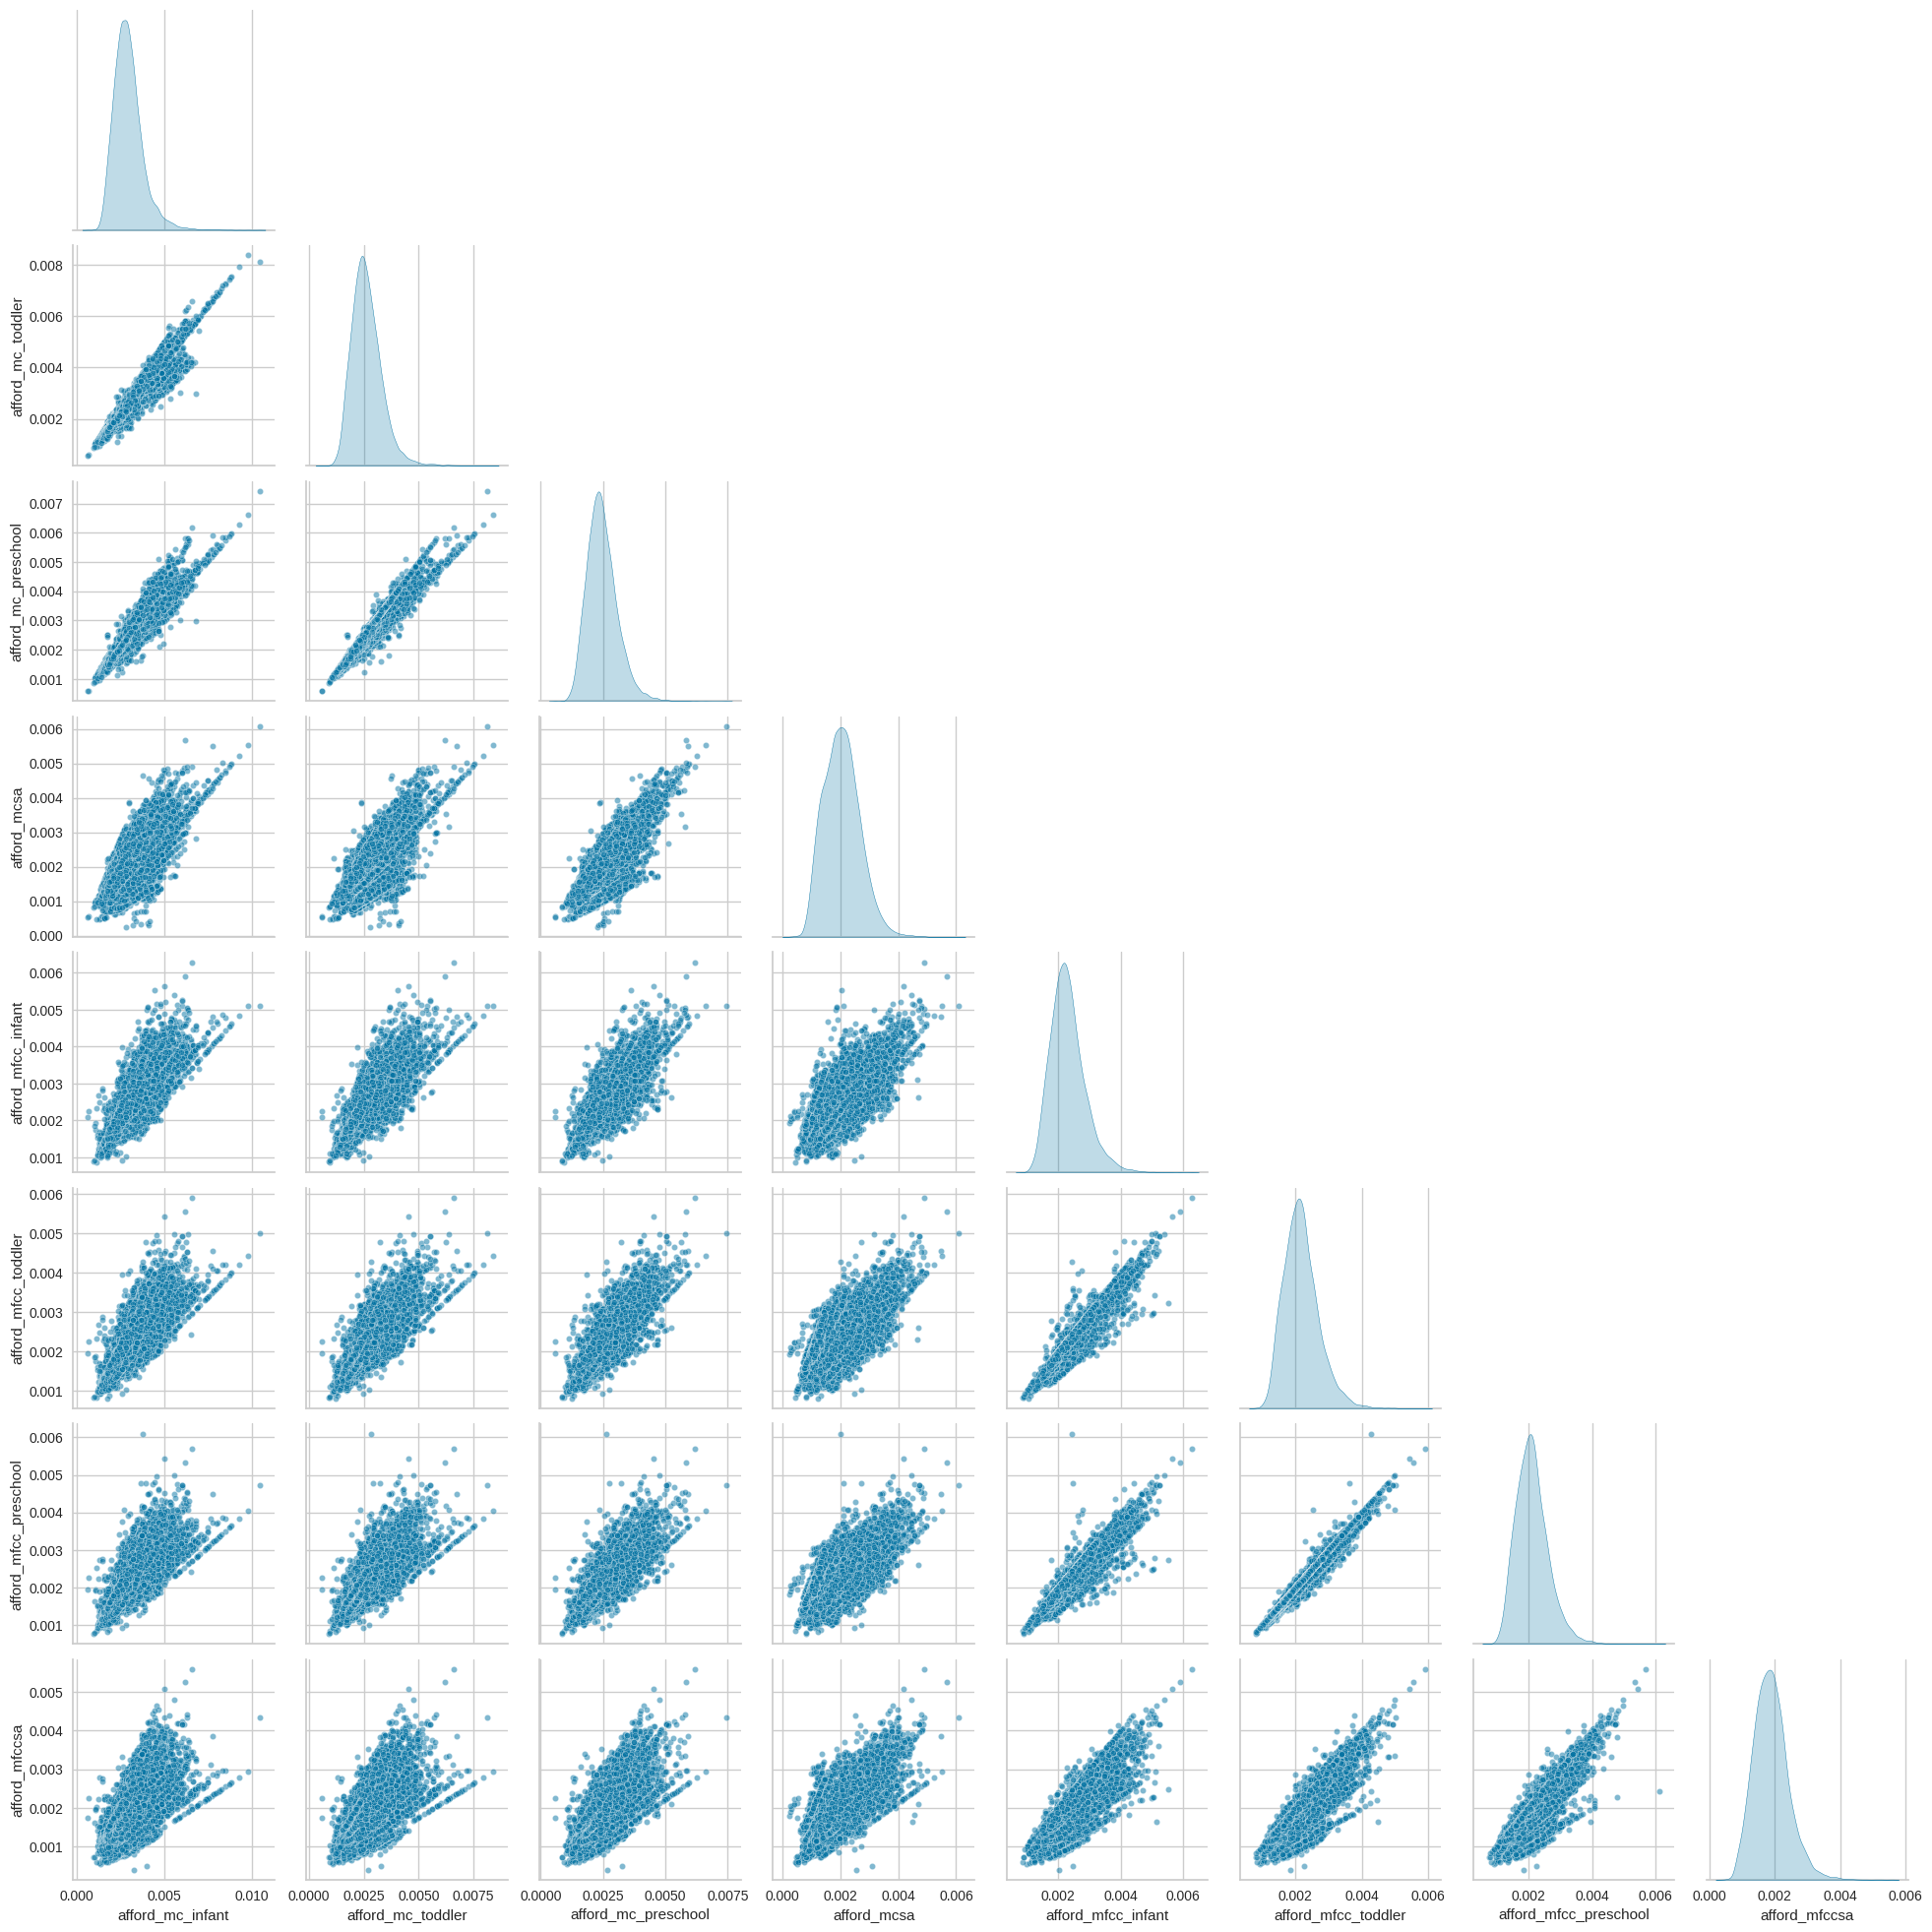

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

cost_df = childcare_clean[afford_cols]

pairplot = sns.pairplot(
    cost_df,
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.5, "s": 20}
)

plt.show()


<Axes: >

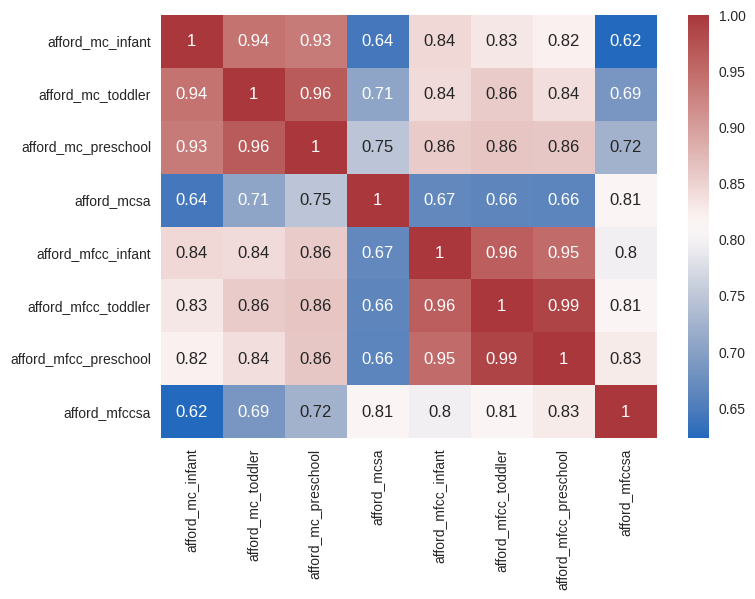

In [72]:
# @title
#plot correlation
corr = cost_df.corr( numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")

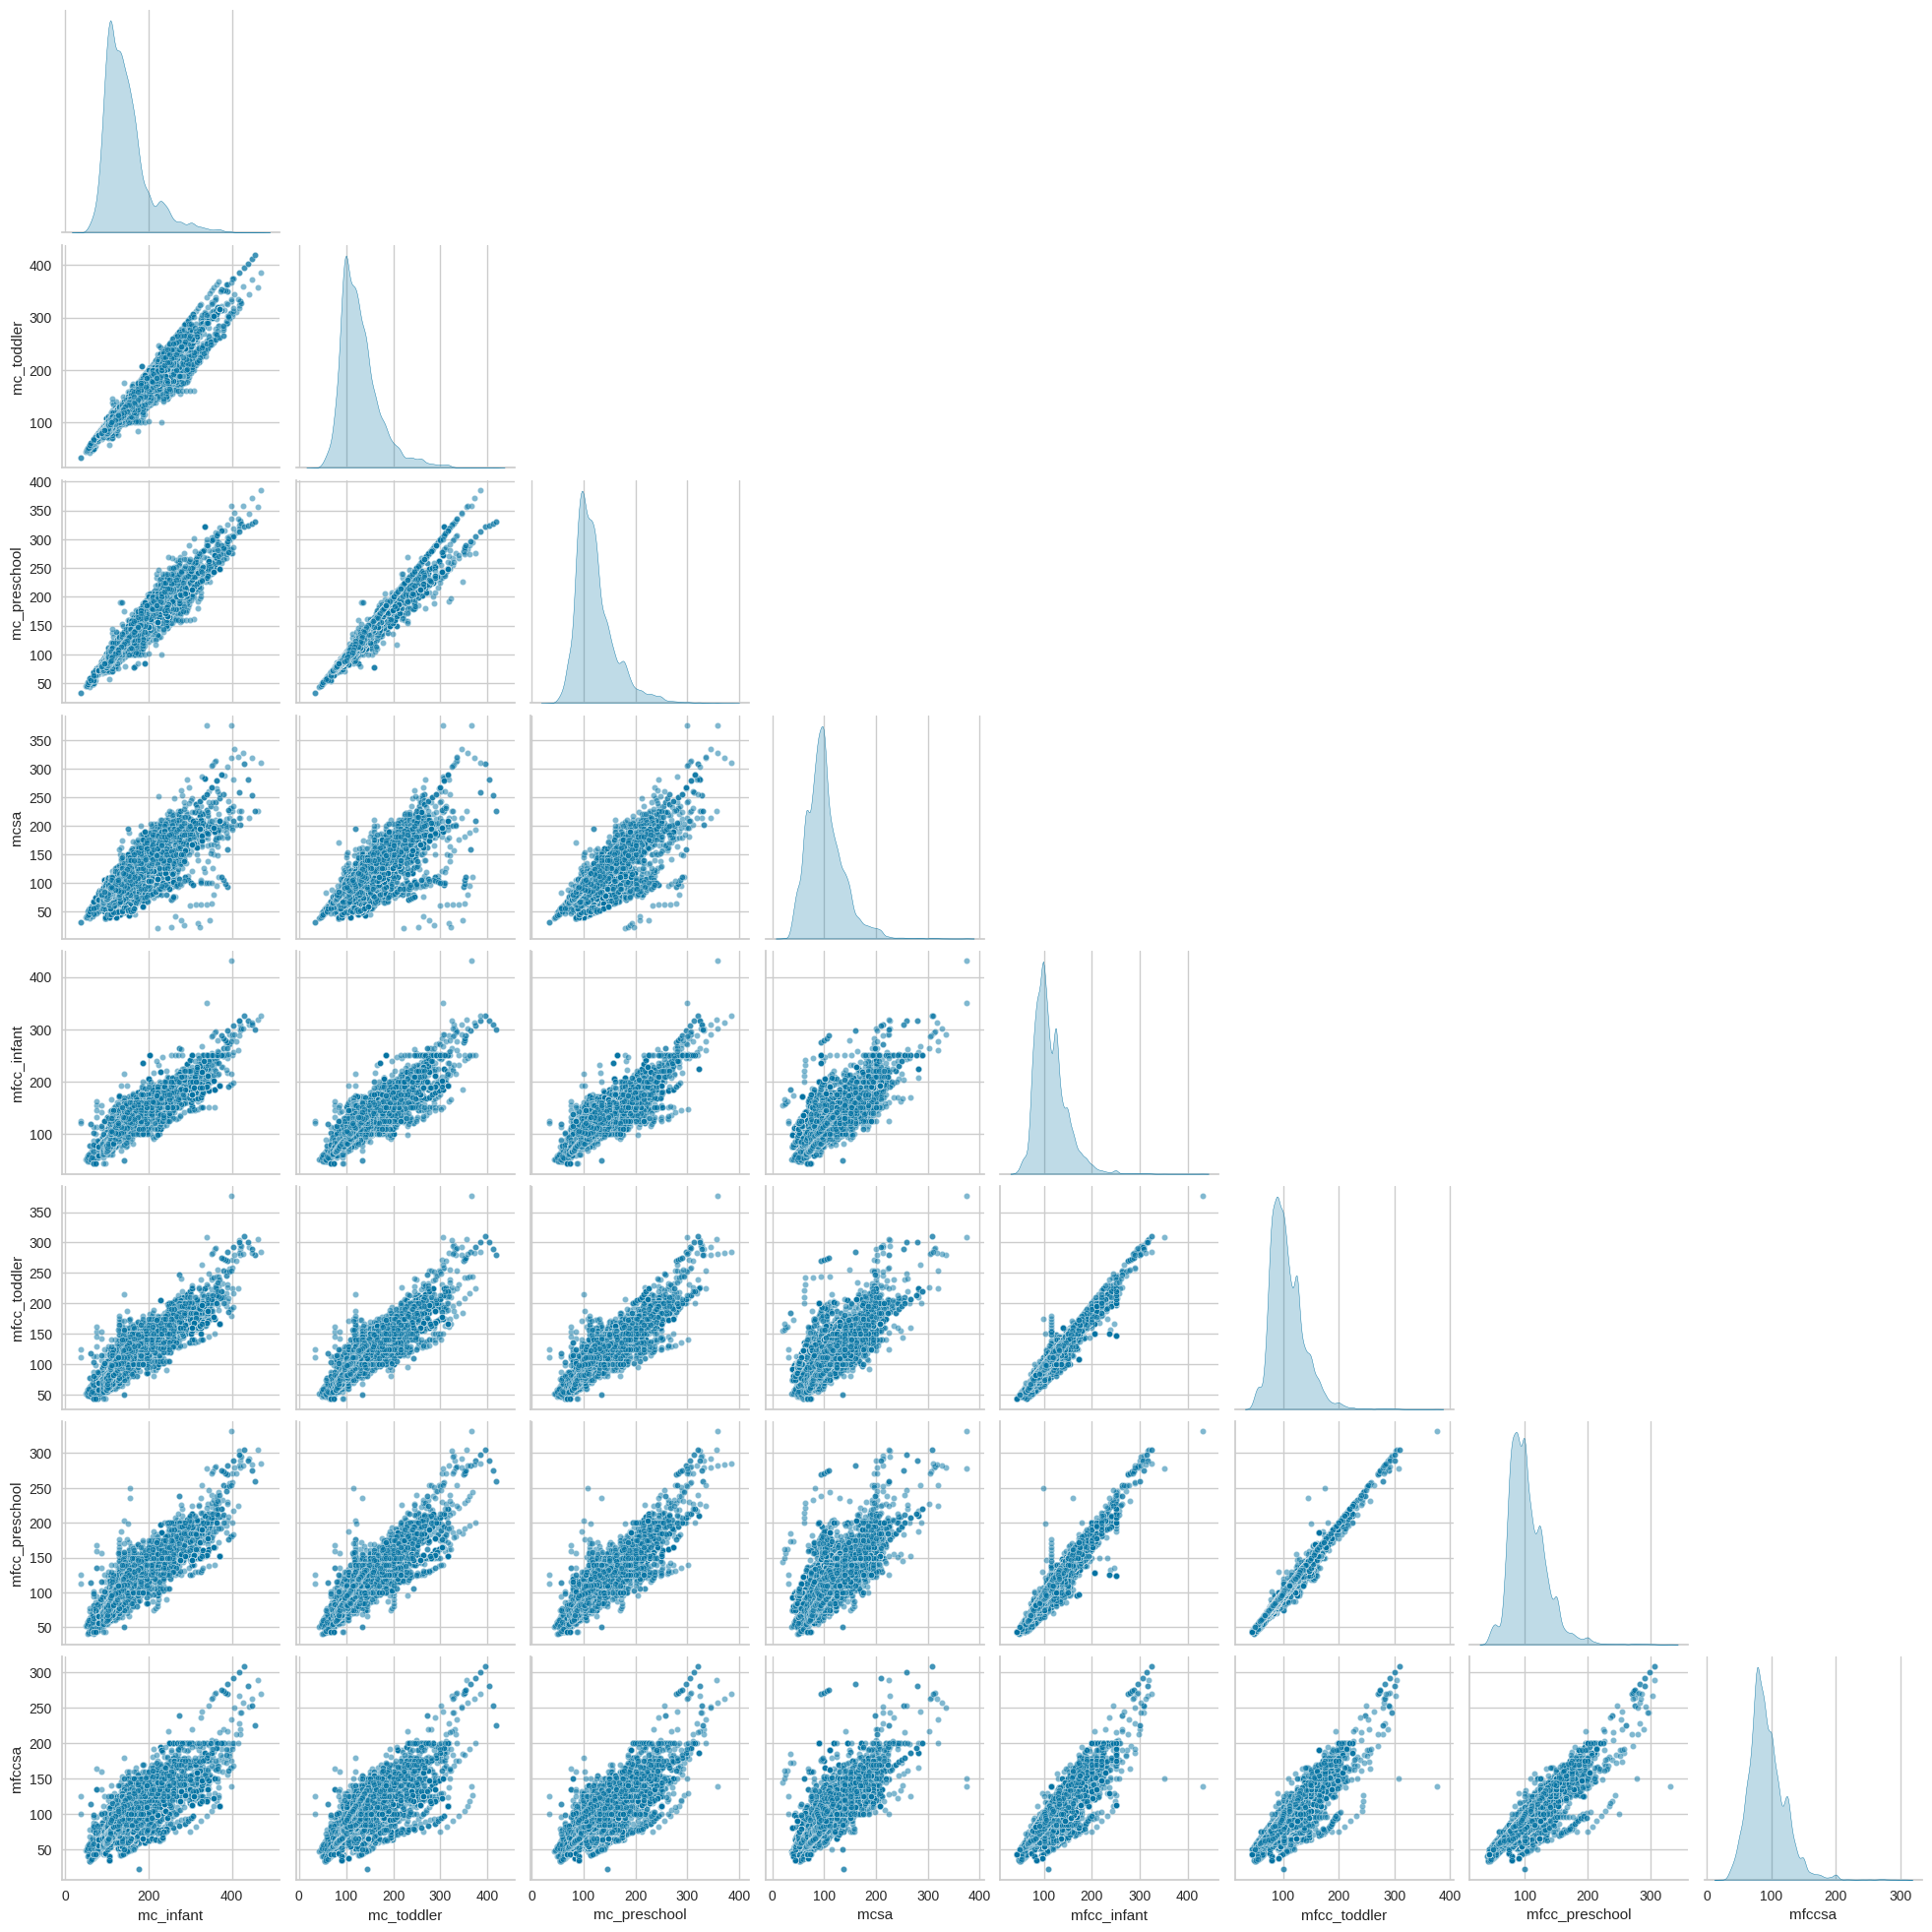

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

cost_df = childcare_clean[cost_cols]

pairplot = sns.pairplot(
    cost_df,
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.5, "s": 20}
)

plt.show()

<Axes: >

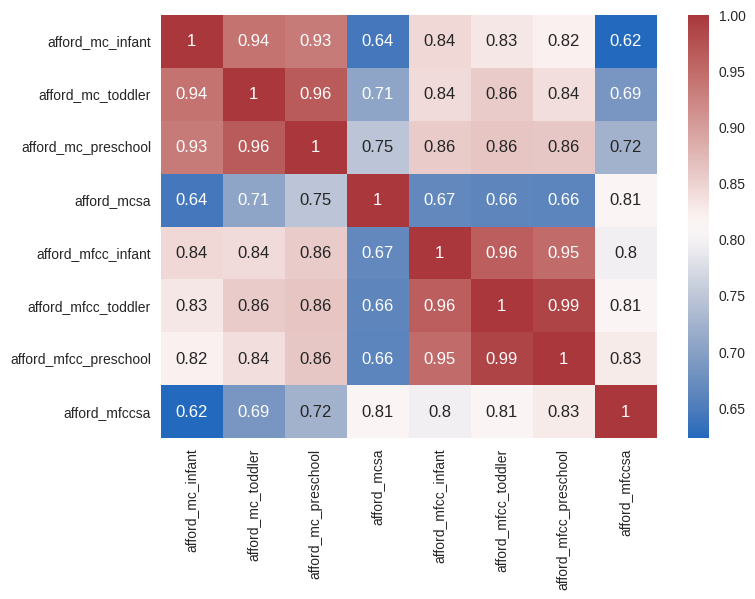

In [74]:
#plot correlation
affordabilty_df = childcare_clean[afford_cols]
corr=affordabilty_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")

### Normalization

In [126]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_cost = childcare_clean[cost_cols]

x_cost_scaled = scaler.fit_transform(x_cost)

x_cost_scaled = pd.DataFrame(
    x_cost_scaled,
    columns=cost_cols,
    index=x_cost.index
)
x_cost_scaled.head()


,mc_infant,mc_toddler,mc_preschool,mcsa,mfcc_infant,mfcc_toddler,mfcc_preschool,mfccsa
0,-0.760837,-0.578337,-0.939269,-0.586440,-0.912068,-0.776245,-0.785747,-0.400439
1,-0.757849,-0.574656,-0.895706,-0.514128,-0.792037,-0.644831,-0.637943,-0.245609
2,-0.754675,-0.570746,-0.852143,-0.441817,-0.672006,-0.513418,-0.490140,-0.090779
3,-0.751500,-0.566836,-0.808581,-0.369216,-0.551671,-0.381671,-0.341991,0.064413
4,-0.748513,-0.563156,-0.765018,-0.296904,-0.431640,-0.250258,-0.194187,0.219243


In [75]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
X_afford = childcare_clean[afford_cols]

scaler = StandardScaler()
X_afford_scaled = scaler.fit_transform(X_afford)

X_afford_scaled = pd.DataFrame(
    X_afford_scaled,
    columns=afford_cols,
    index=X_afford.index
)

X_afford_scaled.head()


,afford_mc_infant,afford_mc_toddler,afford_mc_preschool,afford_mcsa,afford_mfcc_infant,afford_mfcc_toddler,afford_mfcc_preschool,afford_mfccsa
0,-1.355103,-1.194766,-1.613973,-1.075077,-1.546443,-1.406058,-1.418935,-0.940587
1,-1.414577,-1.266420,-1.638306,-1.072973,-1.503888,-1.360442,-1.358761,-0.882051
2,-1.464382,-1.326425,-1.654244,-1.064317,-1.455896,-1.308998,-1.293442,-0.818510
3,-1.413201,-1.264762,-1.554387,-0.945443,-1.278466,-1.118804,-1.087095,-0.617779
4,-1.366776,-1.208831,-1.458064,-0.829212,-1.102572,-0.930258,-0.881893,-0.418162


## Clustering on original data(affordability)

### k-means

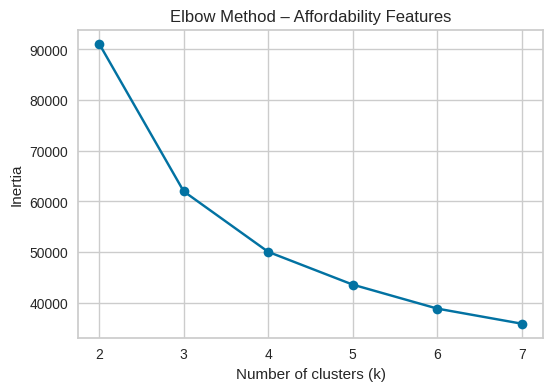

In [76]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_afford_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method – Affordability Features")
plt.show()

In [77]:
from sklearn.metrics import silhouette_score

for k in [3,4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_afford_scaled)
    score = silhouette_score(X_afford_scaled, labels)
    print(f"k={k}, silhouette score={score}")

k=3, silhouette score=0.3761183750477704
k=4, silhouette score=0.3211991454731042


In [78]:
from sklearn.cluster import KMeans
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_afford_scaled)

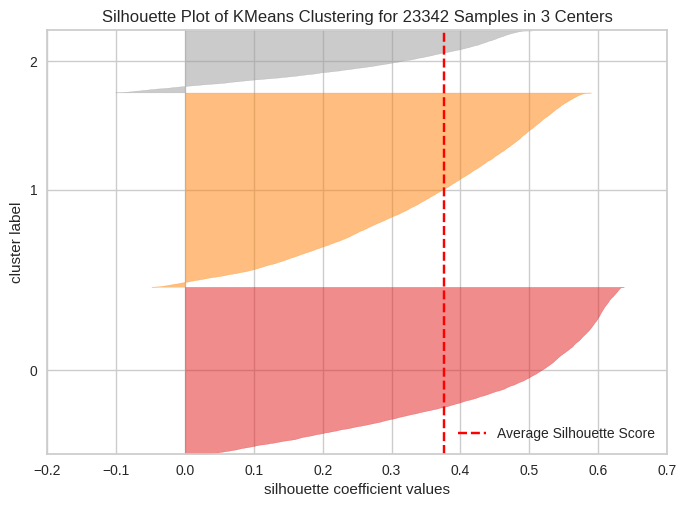

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 23342 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [79]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans

k = 3

model = KMeans(n_clusters=k, random_state=42)
visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_afford_scaled)
visualizer.show()

## PCA

In [80]:
!pip install psynlig -q

### PCA for Cost feature set

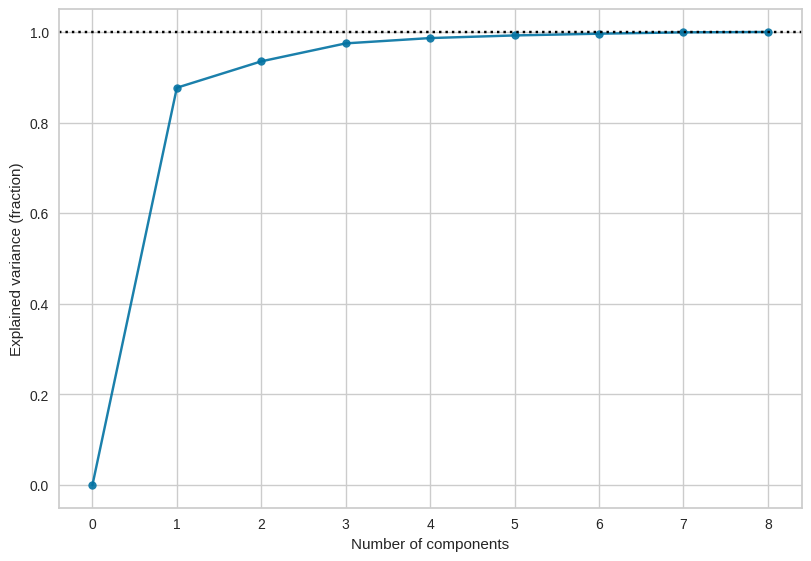

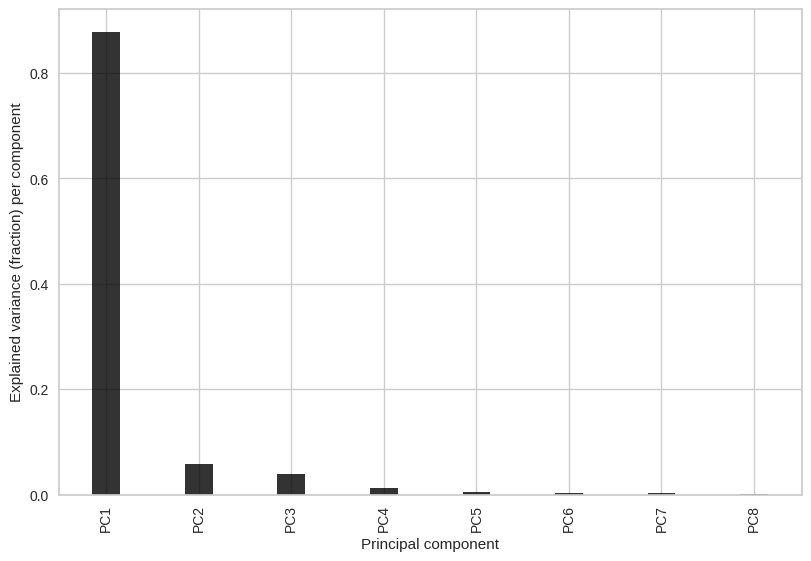

In [127]:
import numpy as np
from sklearn.decomposition import PCA
from psynlig import pca_explained_variance, pca_explained_variance_bar
import matplotlib.pyplot as plt

# Fit PCA (full)
pca_cost = PCA()
pca_cost.fit(x_cost_scaled)

# Prof-style plots (dots included)
_, ax = pca_explained_variance(pca_cost, marker='o', markersize=6, alpha=0.9)
plt.show()

pca_explained_variance_bar(pca_cost, width=0.3, alpha=0.8, color="black")
plt.show()



In [139]:
# Apply PCA with chosen components
pca_cost_model = PCA(n_components=1)
X_pca_cost = pca_cost_model.fit_transform(x_cost_scaled)

# check shape
X_pca_cost.shape

(23342, 1)

In [140]:
# Create the model
model = PCA(1)

#fit the data
model.fit(X_pca_cost)
transformed_data1 = model.transform(X_pca_cost)

In [141]:
import plotly.express as px

transformed_data_df1 = pd.DataFrame(transformed_data1, columns=['PC1'])

fig = px.histogram(
    transformed_data_df1,
    x='PC1',
    nbins=50
)

fig.show()

### PCA for Affordability feature set

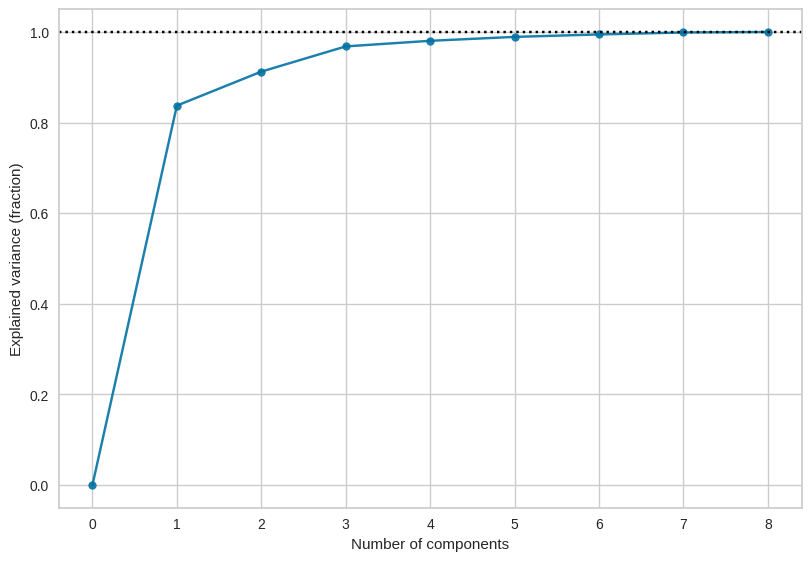

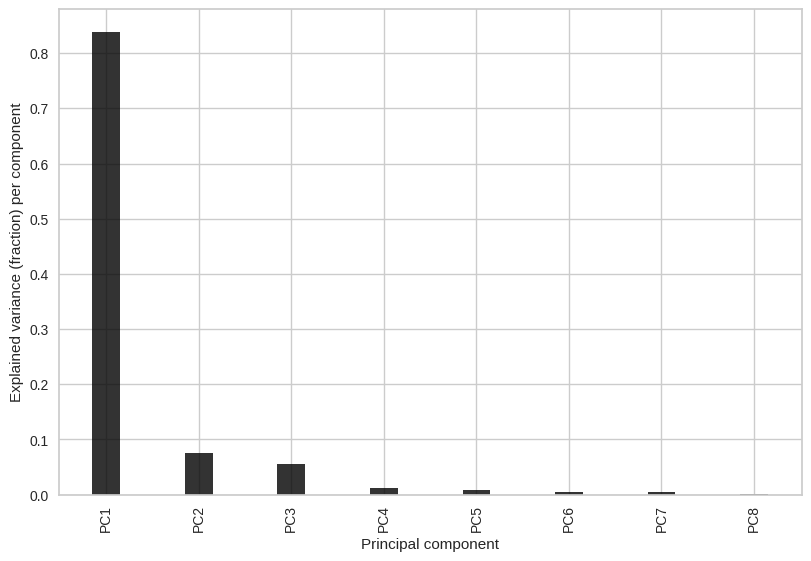

In [81]:
import numpy as np
from sklearn.decomposition import PCA
from psynlig import pca_explained_variance, pca_explained_variance_bar
import matplotlib.pyplot as plt
# Fit PCA (full)
pca_aff = PCA()
pca_aff.fit(X_afford_scaled)

# Prof-style plots (dots included)
_, ax = pca_explained_variance(pca_aff, marker='o', markersize=6, alpha=0.9)
plt.show()

pca_explained_variance_bar(pca_aff, width=0.3, alpha=0.8, color="black")
plt.show()

In [82]:
# Apply PCA with chosen components
pca_aff_model = PCA(n_components=1)
X_pca_aff = pca_aff_model.fit_transform(X_afford_scaled)

# check shape
X_pca_aff.shape

(23342, 1)

In [83]:
# Create the model
model = PCA(1)

#fit the data
model.fit(X_pca_aff)
transformed_data = model.transform(X_pca_aff)

In [84]:
import plotly.express as px

transformed_data_df = pd.DataFrame(transformed_data, columns=['PC1'])

fig = px.histogram(
    transformed_data_df,
    x='PC1',
    nbins=50
)

fig.show()

## Clustering on PCA data(cost)

### Hierarchical

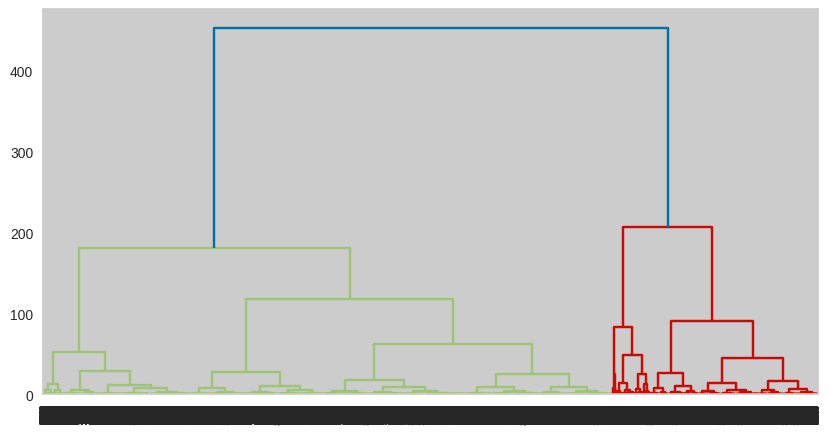

In [163]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt

Z = linkage(transformed_data1, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.show()

In [164]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2,6):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(transformed_data1)

    score = silhouette_score(transformed_data1, labels)

    print(f"K={k}, Silhouette={score:.4f}")

K=2, Silhouette=0.6166
K=3, Silhouette=0.5765
K=4, Silhouette=0.4866
K=5, Silhouette=0.4768


### K-Means

In [142]:
from sklearn.metrics import silhouette_score

for k in range(2,6):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(transformed_data1)
    score = silhouette_score(transformed_data1, model.labels_)
    print(k, score)

2 0.6169248966791374
3 0.560121846766421
4 0.5460258174691945
5 0.5115875480486206


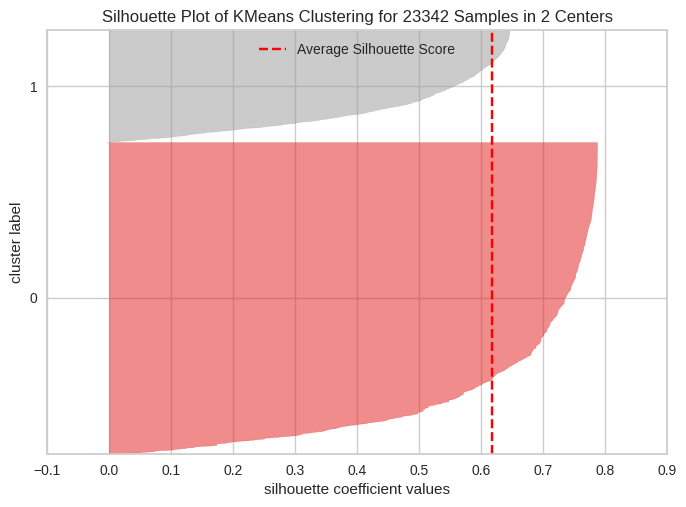

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 23342 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [144]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(2, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_pca_cost)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

In [146]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(transformed_data1)

labels = kmeans.labels_

In [149]:
transformed_data_df1 = pd.DataFrame(transformed_data1, columns=['PC1'])
transformed_data_df1['cluster1'] = labels

In [150]:
import plotly.express as px

transformed_data_df1['y'] = 0

fig = px.scatter(
    transformed_data_df1,
    x='PC1',
    y='y',
    color='cluster1'
)

fig.update_yaxes(visible=False)
fig.show()

In [151]:
transformed_data_df1

,PC1,cluster1,y
0,-2.043729,0,0
1,-1.805794,0,0
2,-1.567709,0,0
3,-1.329053,0,0
4,-1.091118,0,0
...,...,...,...
23337,0.214724,0,0
23338,0.110147,0,0
23339,0.039294,0,0
23340,-0.031426,0,0


In [153]:
transformed_data_df1.groupby('cluster1')['PC1'].mean()

,PC1
cluster1,
0,-1.255082
1,3.503873


## Clustering on PCA data(affordability)

### Hierarchical

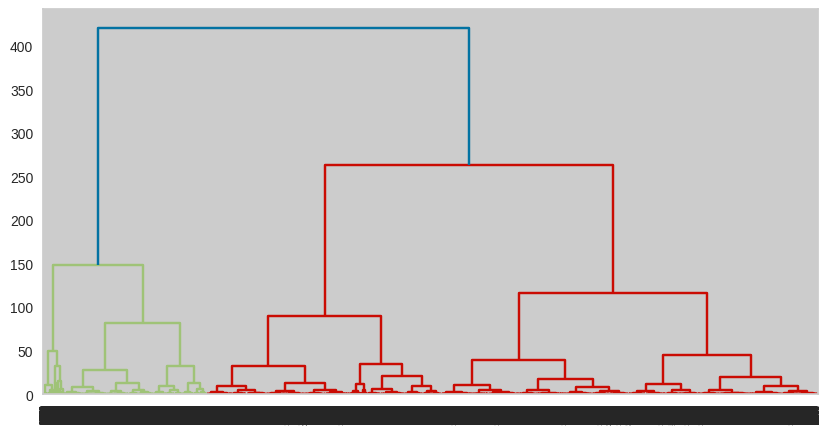

In [94]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt

Z = linkage(transformed_data, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.show()

In [97]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2,6):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(transformed_data)

    score = silhouette_score(transformed_data, labels)

    print(f"K={k}, Silhouette={score:.4f}")

K=2, Silhouette=0.5602
K=3, Silhouette=0.5323
K=4, Silhouette=0.5301
K=5, Silhouette=0.4958


### K-Means

In [86]:
from sklearn.metrics import silhouette_score

for k in range(2,6):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(transformed_data)
    score = silhouette_score(transformed_data, model.labels_)
    print(k, score)

2 0.5554850260013885
3 0.5429784324760643
4 0.5305138534176854
5 0.526657643594589


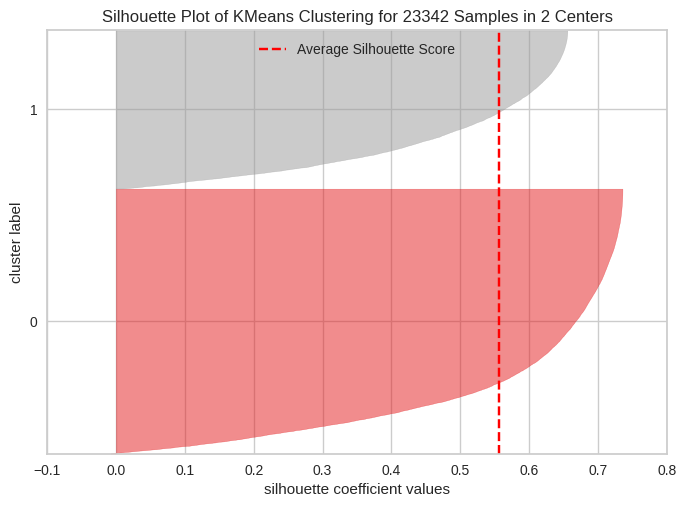

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 23342 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [145]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(2, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_pca_aff)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

In [88]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(transformed_data)

labels = kmeans.labels_

In [155]:
transformed_data_df = pd.DataFrame(transformed_data, columns=['PC1'])
transformed_data_df['cluster'] = labels

In [90]:
import plotly.express as px

transformed_data_df['y'] = 0

fig = px.scatter(
    transformed_data_df,
    x='PC1',
    y='y',
    color='cluster'
)

fig.update_yaxes(visible=False)
fig.show()

In [91]:
transformed_data_df

,PC1,cluster,y
0,-3.752705,0,0
1,-3.733975,0,0
2,-3.694830,0,0
3,-3.303731,0,0
4,-2.920455,0,0
...,...,...,...
23337,-1.274865,0,0
23338,-2.014781,0,0
23339,-1.674261,0,0
23340,-2.192655,0,0


In [104]:
transformed_data_df.groupby('cluster')['PC1'].mean()

,PC1
cluster,
0,-1.563212
1,2.619330


In [166]:
childcare_clean['cluster_cost']=transformed_data_df1['cluster1'].values
childcare_clean['pc1_cost']=transformed_data_df1['PC1'].values
childcare_clean['cluster_afford']=transformed_data_df['cluster'].values
childcare_clean['pc1_afford']=transformed_data_df['PC1'].values
childcare_clean

/tmp/ipython-input-4066072926.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-4066072926.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-4066072926.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-406

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,afford_mcsa,afford_mfcc_infant,afford_mfcc_toddler,afford_mfcc_preschool,afford_mfccsa,cluster_afford,pc1,pc1_afford,cluster_cost,pc1_cost
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,0.001384,0.001427,0.001427,0.001392,0.001392,0,-3.752705,-2.043729,0,-2.043729
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,0.001385,0.001451,0.001451,0.001423,0.001423,0,-3.733975,-1.805794,0,-1.805794
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,0.001391,0.001478,0.001478,0.001456,0.001456,0,-3.694830,-1.567709,0,-1.567709
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,0.001465,0.001578,0.001578,0.001561,0.001561,0,-3.303731,-1.329053,0,-1.329053
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,0.001537,0.001677,0.001677,0.001666,0.001666,0,-2.920455,-1.091118,0,-1.091118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34562,56045,2014,3.60,5.36,2.28,2.4,4.8,0.6,75.9,74.8,...,0.001595,0.001937,0.001937,0.001950,0.001976,0,-1.274865,0.214724,0,0.214724
34563,56045,2015,5.16,7.86,3.16,4.2,7.6,1.6,73.2,82.0,...,0.001548,0.001812,0.001812,0.001812,0.001812,0,-2.014781,0.110147,0,0.110147
34564,56045,2016,3.61,4.67,2.79,3.4,4.5,2.6,69.7,68.1,...,0.001684,0.001953,0.001901,0.001888,0.001863,0,-1.674261,0.039294,0,0.039294
34565,56045,2017,2.24,2.64,1.95,2.3,2.8,2.0,71.4,63.6,...,0.001662,0.001911,0.001812,0.001787,0.001740,0,-2.192655,-0.031426,0,-0.031426


Checking whether the representation of two segmentations are same

In [168]:
pd.crosstab(childcare_clean['cluster_cost'], childcare_clean['cluster_afford'])

cluster_afford,0,1
cluster_cost,,
0,17186,0
1,0,6156


## Analysis
Q3: How are childcare cost clusters structurally associated with labor market and household characteristics?

In [158]:
childcare_clean['cluster_cost'].value_counts()

,count
cluster_cost,
0,17186
1,6156


In [160]:
childcare_clean.groupby('cluster_cost')['mhi_2018'].mean()

,mhi_2018
cluster_cost,
0,46583.557053
1,61162.374496


In [161]:
fig = px.scatter(
    childcare_clean,
    x='mhi_2018',
    y='mc_infant',
    color='cluster_cost'
)

fig.show()

 flfpr_20to64_under6 (labor force participation rate of the female population aged 20 to 64 years old who have children under 6 years old) group by cluster_cost

In [162]:
childcare_clean.groupby('cluster_cost')['flfpr_20to64_under6'].mean()

,flfpr_20to64_under6
cluster_cost,
0,67.938970
1,70.328905


`h_under6_both_work`: Number of households with children under 6 years old with two parents that are both working.

`h_under6_single_m`: Number of households with children under 6 years old with a single mother.



In [170]:
childcare_clean.groupby('cluster_cost')['h_under6_both_work'].mean()

,h_under6_both_work
cluster_cost,
0,1399.678168
1,7646.686160


In [171]:
childcare_clean.groupby('cluster_cost')['h_under6_single_m'].mean()

,h_under6_single_m
cluster_cost,
0,1196.567904
1,4913.425439


In [172]:
fig = px.scatter(
    childcare_clean,
    x='h_under6_both_work',
    y='mc_infant',
    color='cluster_cost'
)

fig.show()

### analysis affordability cluster

In [159]:
childcare_clean['cluster_afford'].value_counts()

,count
cluster_afford,
0,17186
1,6156


check the average of childcare cost

In [117]:
childcare_clean.groupby('cluster_afford')['afford_mfcc_infant'].mean()
childcare_clean.groupby('cluster_afford')['afford_mc_toddler'].mean()

,afford_mc_toddler
cluster_afford,
0,0.002232
1,0.003272


we find thar cluster0 = low burden, cluster1 = high burden

labor market

In [118]:
childcare_clean.groupby('cluster_afford')['mhi_2018'].mean()

,mhi_2018
cluster_afford,
0,52924.626887
1,46245.803882


In [120]:
#plot the cluster
import plotly.express as px

fig = px.box(
    childcare_clean,
    x='cluster_afford',
    y='flfpr_20to64_under6',
    color='cluster_afford'
)
fig.show()
